**I.Nhập thư viện và đọc dataset**

In [ ]:
# Import các thư viện cần thiết
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from imblearn.over_sampling import SMOTE

# Cấu hình hiển thị
pd.set_option('display.max_columns', 100)
sns.set(style='whitegrid', palette='Set2')


In [ ]:
# Đọc dataset

link='https://drive.google.com/file/d/1wB60LiKl58sqRWWZ6Cyhu0RXkMWKCcMn/view?usp=sharing'
# Nguồn data https://raw.githubusercontent.com/srafay/Machine_Learning_A-Z/master/Part%204%20-%20Clustering/Section%2024%20-%20K-Means%20Clustering/Mall_Customers.csv
#Đọc data
path = 'https://drive.google.com/uc?export=download&id='+link.split('/')[-2]
df = pd.read_csv(path,encoding= 'unicode_escape')
print('Shape:', df.shape)
df.head()

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


**II. Cleaning Data**

In [ ]:
# Thông tin tổng quan
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
# Thống kê mô tả numeric
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [ ]:
#Kiểm tra null
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
#Kiểm tra trùng
df.duplicated().sum()

np.int64(0)

In [ ]:
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
df[numeric_cols].describe()


,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


**Tạo thêm các cột cần thiết**

In [ ]:
#Chuẩn hoá kiểu dữ liệu (Datetime)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df[['Order Date', 'Ship Date']].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


In [ ]:
#Tạo cột Order Year và Order Month
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month

df[['Order Year', 'Order Month']].dtypes

,0
Order Year,int32
Order Month,int32


In [ ]:
#Tạo cột Profit Margin và Shipping_days
df['Profit_Margin'] = df['Profit'] / df['Sales']
df['Shipping_Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df[['Profit_Margin','Shipping_Days']].describe()


,Profit_Margin,Shipping_Days
count,9994.000000,9994.000000
mean,0.120314,3.958175
std,0.466754,1.747567
min,-2.750000,0.000000
25%,0.075000,3.000000
50%,0.270000,4.000000
75%,0.362500,5.000000
max,0.500000,7.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

**EDA Data**

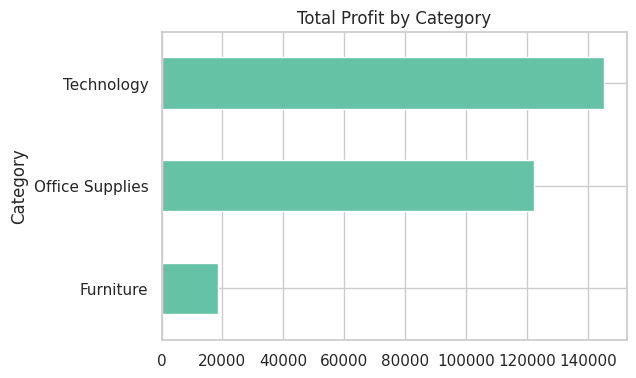

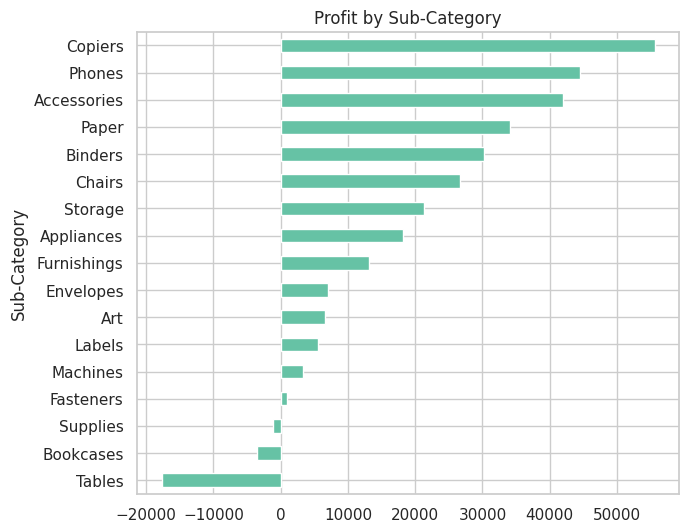

In [ ]:
# Lợi nhuận của Category
cat_profit = df.groupby('Category')['Profit'].sum().sort_values()

cat_profit.plot(kind='barh', figsize=(6,4))
plt.title("Total Profit by Category")
plt.show()

# Lợi nhuận của Sub-Category
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

plt.figure(figsize=(7,6))
subcat_profit.plot(kind='barh')
plt.title("Profit by Sub-Category")
plt.show()


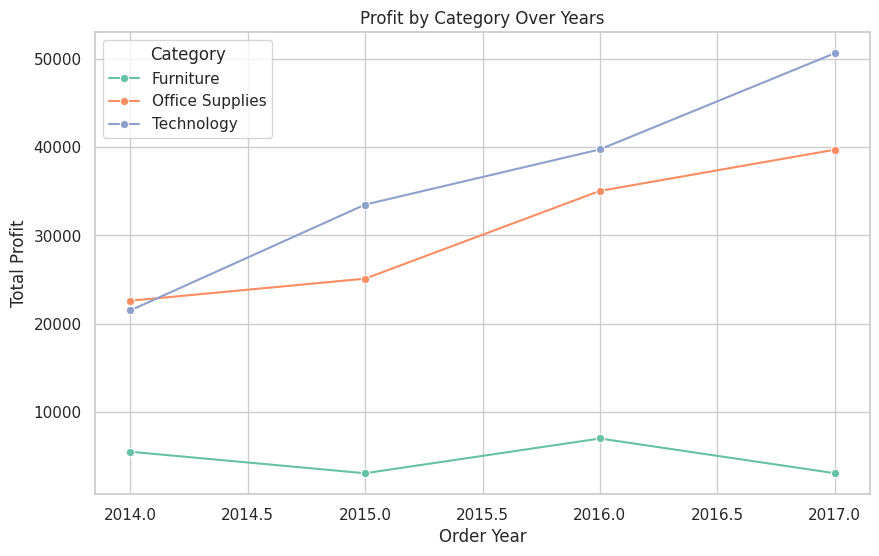

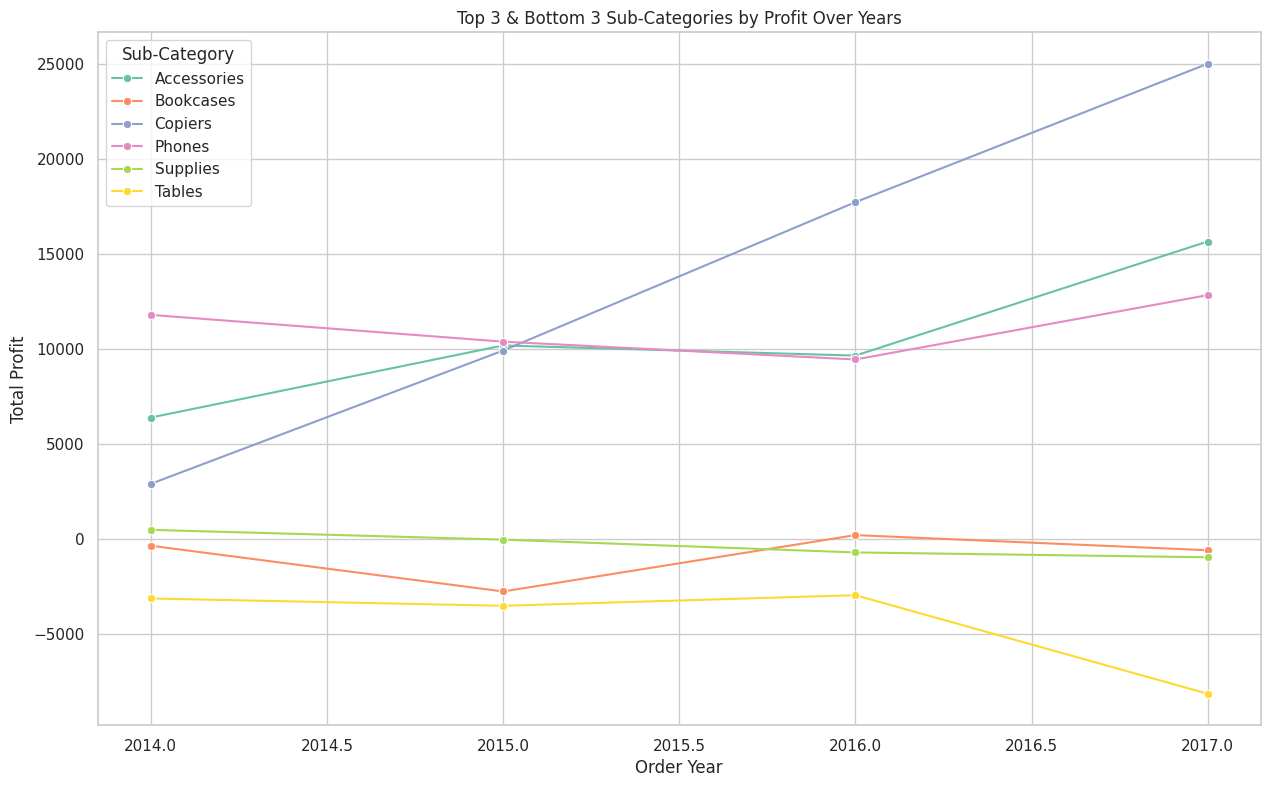

In [ ]:
#Lợi nhuận của Category qua các năm
profit_category_year = (
    df.groupby(['Order Year', 'Category'])['Profit']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=profit_category_year,
    x='Order Year',
    y='Profit',
    hue='Category',
    marker='o'
)

plt.title('Profit by Category Over Years')
plt.xlabel('Order Year')
plt.ylabel('Total Profit')
plt.grid(True)
plt.show()

#Lợi nhuận của Sub-Category qua các năm
##Tính tổng profit toàn thời gian theo Sub-Category
sub_profit_total = (
    df.groupby('Sub-Category')['Profit']
    .sum()
    .sort_values(ascending=False)
)

##Lấy Top 3 & Bottom 3 Sub-Category
top_3_sub = sub_profit_total.head(3).index
bottom_3_sub = sub_profit_total.tail(3).index

selected_subs = list(top_3_sub) + list(bottom_3_sub)

##Lợi nhuận của Top 3 & Bottom 3 Sub-Category qua các năm
profit_subcategory_year = (
    df[df['Sub-Category'].isin(selected_subs)]
    .groupby(['Order Year', 'Sub-Category'])['Profit']
    .sum()
    .reset_index()
)

##Vẽ biểu đồ
plt.figure(figsize=(15, 9))
sns.lineplot(
    data=profit_subcategory_year,
    x='Order Year',
    y='Profit',
    hue='Sub-Category',
    marker='o'
)
plt.title('Top 3 & Bottom 3 Sub-Categories by Profit Over Years')
plt.xlabel('Order Year')
plt.ylabel('Total Profit')
plt.grid(True)
plt.show()


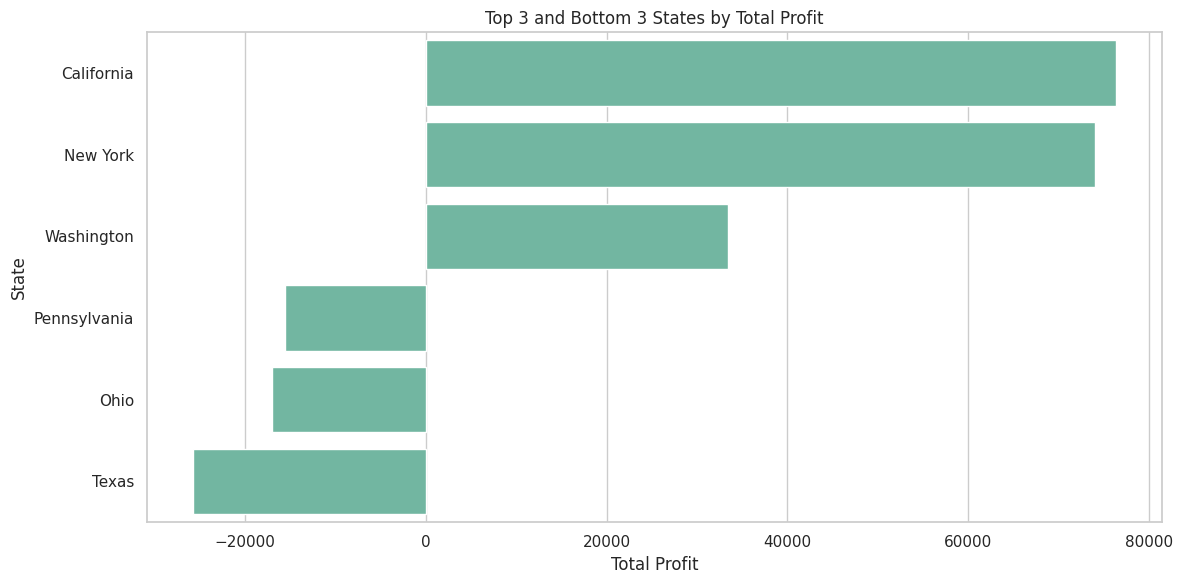

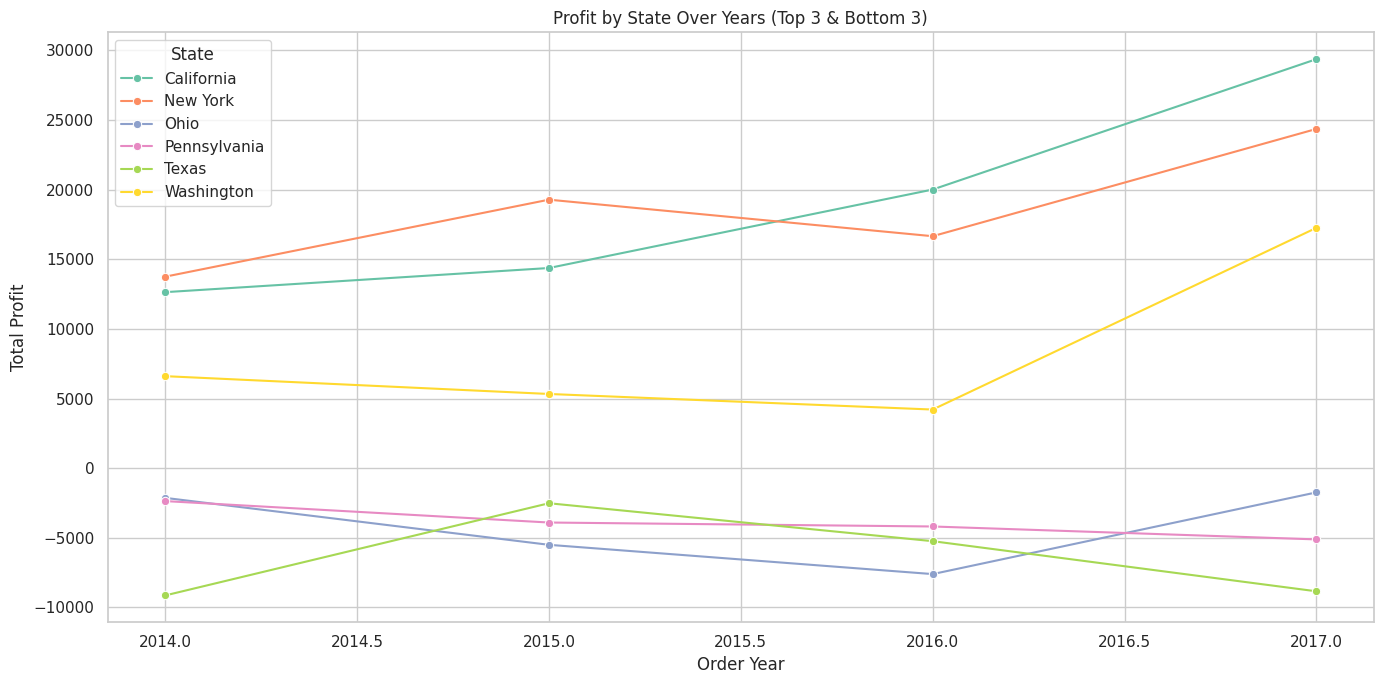

In [ ]:
#Lợi nhuận trên các bang
# Tổng lợi nhuận theo bang
profit_by_state = (
    df.groupby('State')['Profit']
    .sum()
    .sort_values(ascending=False)
)

# Top 3 và Bottom 3
top_3_states = profit_by_state.head(3)
bottom_3_states = profit_by_state.tail(3)

# Gộp lại
selected_states = pd.concat([top_3_states, bottom_3_states]).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(
    data=selected_states,
    x='Profit',
    y='State'
)

plt.title('Top 3 and Bottom 3 States by Total Profit')
plt.xlabel('Total Profit')
plt.ylabel('State')
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()


# Lấy Top 6 bang có tổng profit cao nhất để tránh biểu đồ quá rối
profit_state_year = (
    df[df['State'].isin(selected_states['State'])]
    .groupby(['Order Year', 'State'])['Profit']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=profit_state_year,
    x='Order Year',
    y='Profit',
    hue='State',
    marker='o'
)

plt.title('Profit by State Over Years (Top 3 & Bottom 3)')
plt.xlabel('Order Year')
plt.ylabel('Total Profit')
plt.grid(True)
plt.tight_layout()
plt.show()


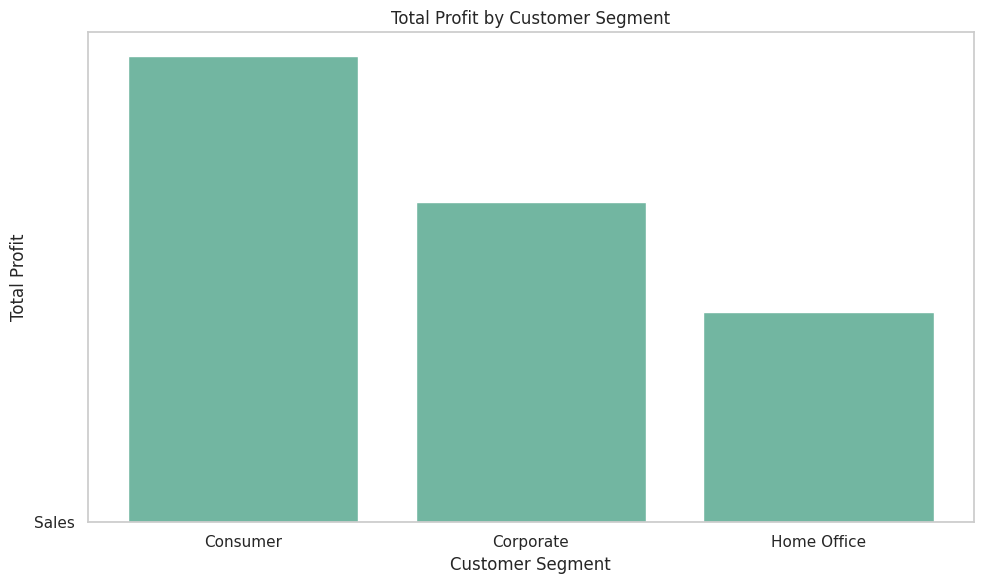

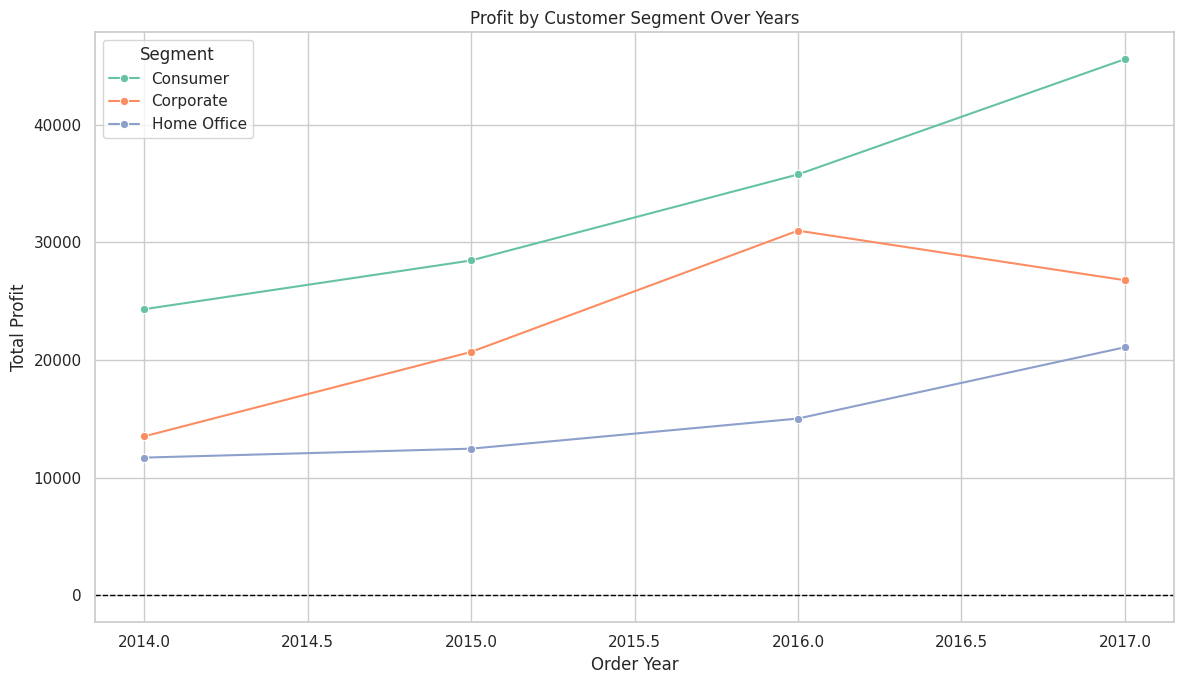

In [ ]:
#Lợi nhuận theo phân khúc khách hàng
profit_by_segment = (
    df.groupby('Segment')['Profit']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=profit_by_segment,
    x='Segment',
    y='Profit'
)

plt.title('Total Profit by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Profit')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()
#Lợi nhuận phân khúc khách hàng qua các năm
profit_segment_year = (
    df.groupby(['Order Year', 'Segment'])['Profit']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=profit_segment_year,
    x='Order Year',
    y='Profit',
    hue='Segment',
    marker='o'
)

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Profit by Customer Segment Over Years')
plt.xlabel('Order Year')
plt.ylabel('Total Profit')
plt.legend(title='Segment')
plt.grid(True)
plt.tight_layout()
plt.show()

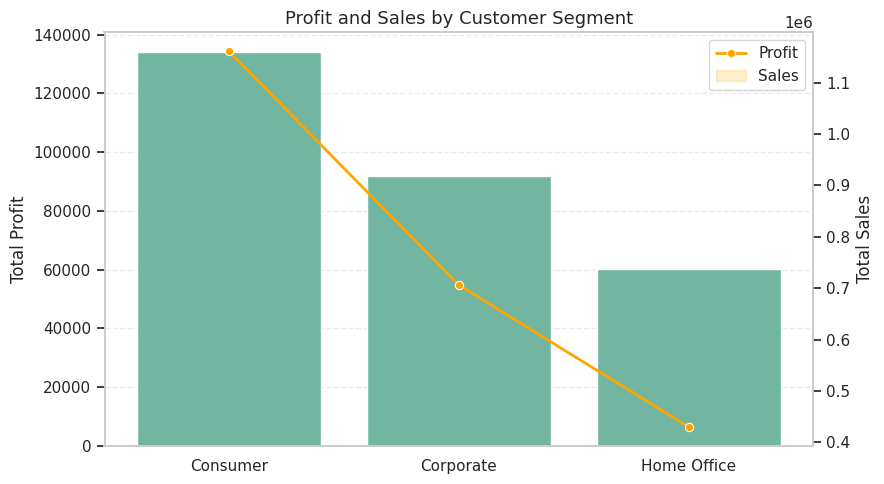

In [ ]:
# Profit & Sales theo phân khúc khách hàng
segment_summary = (
    df.groupby('Segment')[['Profit', 'Sales']]
    .sum()
    .sort_values(by='Profit', ascending=False)
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(9, 5))

# --- Bar: Profit (màu mặc định seaborn) ---
sns.barplot(
    data=segment_summary,
    x='Segment',
    y='Profit',
    ax=ax1
)

ax1.set_ylabel('Total Profit')
ax1.set_xlabel('')
ax1.set_title('Profit and Sales by Customer Segment', fontsize=13)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# --- Line: Sales (đổi màu) ---
ax2 = ax1.twinx()

sns.lineplot(
    data=segment_summary,
    x='Segment',
    y='Sales',
    ax=ax2,
    marker='o',
    color='orange',      # 👈 đổi màu line
    linewidth=2
)

ax2.set_ylabel('Total Sales')
ax2.grid(False)

# --- Legend gọn ---
ax2.legend(['Profit', 'Sales'], loc='upper right')

plt.tight_layout()
plt.show()


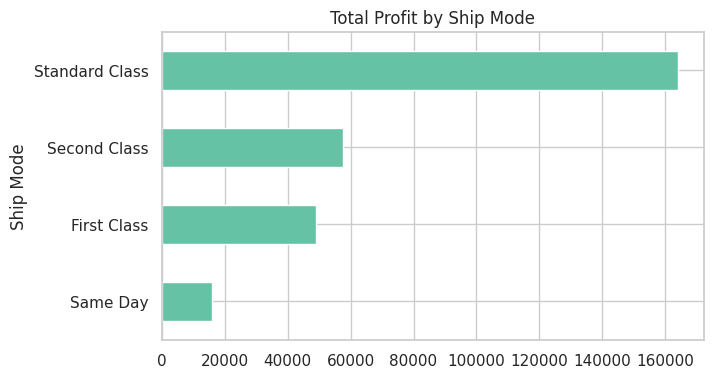

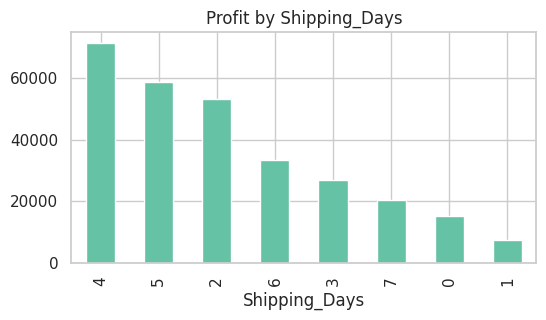

In [ ]:
# Lợi nhuận dựa trên Shipping Mode
ShipM_profit = df.groupby('Ship Mode')['Profit'].sum().sort_values()

ShipM_profit.plot(kind='barh', figsize=(7,4))
plt.title("Total Profit by Ship Mode")
plt.show()

# Lợi nhuận của Sub-Category
ShipD_profit = df.groupby('Shipping_Days')['Profit'].sum().sort_values(ascending=False)

ShipD_profit.plot(kind='bar',figsize=(6,3))
plt.title("Profit by Shipping_Days")
plt.show()

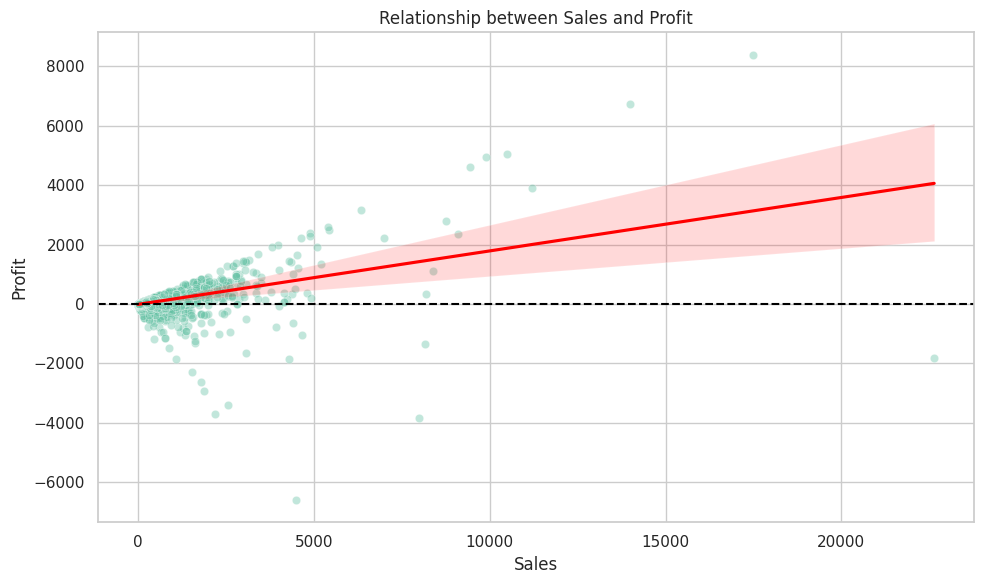

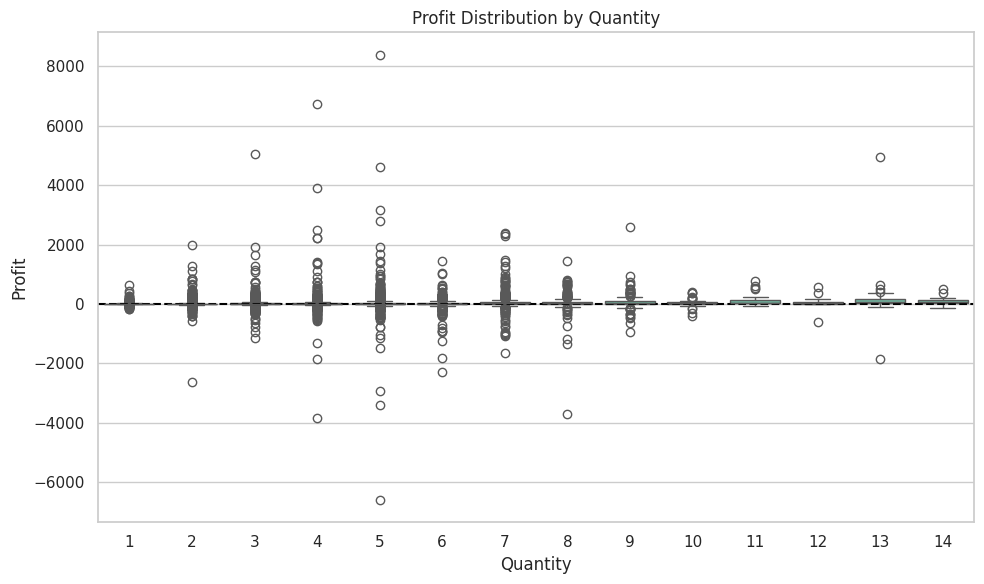

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Sales',
    y='Profit',
    alpha=0.4
)

sns.regplot(
    data=df,
    x='Sales',
    y='Profit',
    scatter=False,
    color='red'
)

plt.title('Relationship between Sales and Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.axhline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='Quantity',
    y='Profit'
)

plt.axhline(0, color='black', linestyle='--')
plt.title('Profit Distribution by Quantity')
plt.xlabel('Quantity')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

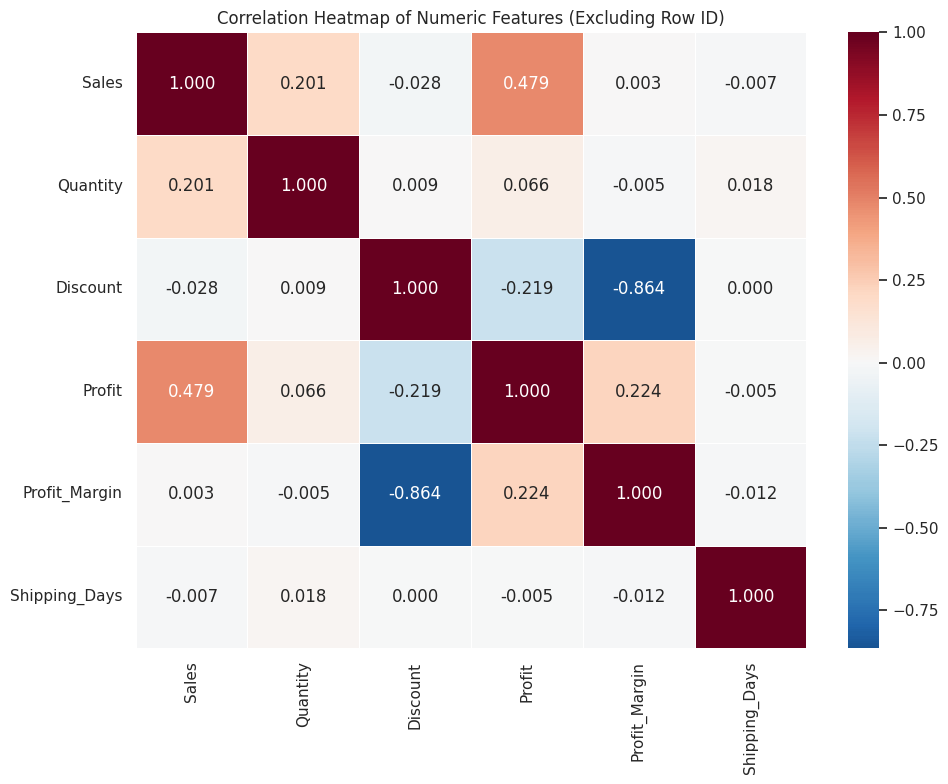

In [ ]:
#Heatmap thể hiện sự tương quan của các biến numberic với Profit
# Chọn các cột numeric nhưng loại bỏ Row ID
numeric_cols = df.select_dtypes(include=['int64', 'float64']).drop(columns=['Row ID','Postal Code'], errors='ignore')

# Tính ma trận tương quan
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt='.3f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numeric Features (Excluding Row ID)')
plt.tight_layout()
plt.show()

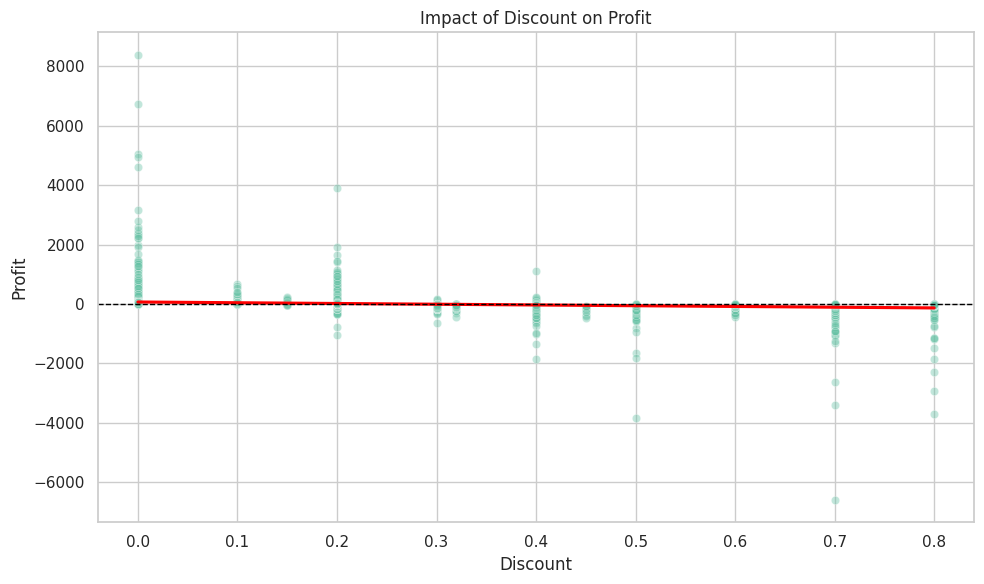

In [ ]:
#Thể hiện sự ảnh hưởng của discount đối với Profit
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    alpha=0.4
)

sns.regplot(
    data=df,
    x='Discount',
    y='Profit',
    scatter=False,
    color='red'
)

plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title('Impact of Discount on Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.grid(True)
plt.tight_layout()
plt.show()

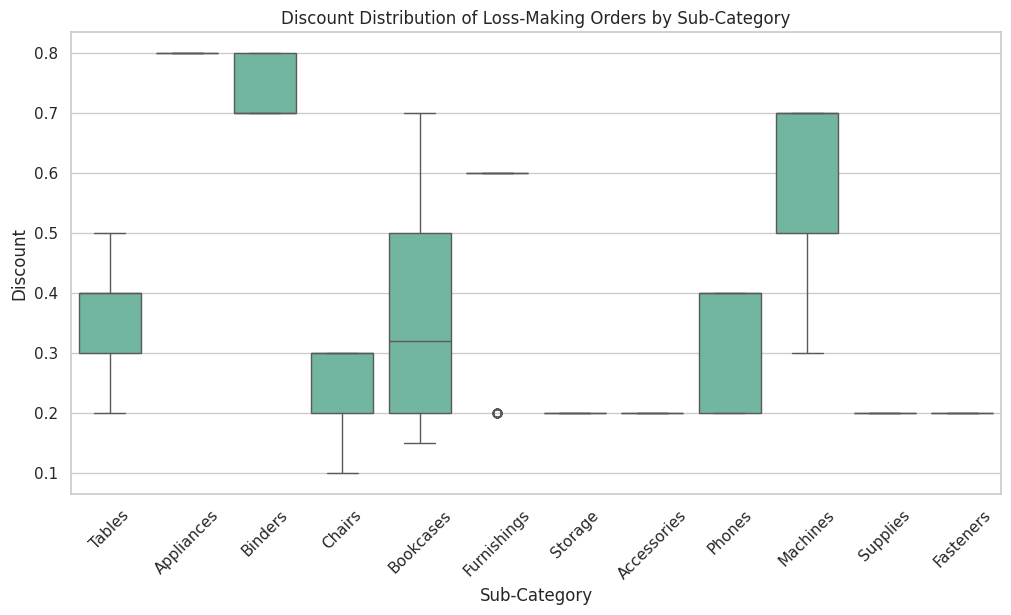

In [ ]:
loss_df = df[df['Profit'] < 0]
plt.figure(figsize=(12,6))
sns.boxplot(
    data=loss_df,
    x='Sub-Category',
    y='Discount'
)

plt.xticks(rotation=45)
plt.title('Discount Distribution of Loss-Making Orders by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Discount')
plt.show()



**Chạy các mô hình có thể sử dụng**

In [ ]:
#Feature Engineering
df = df.copy()

# Shipping duration
df['Shipping_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Discount impact
df['Discount_Impact'] = df['Sales'] * df['Discount']

# Sales per quantity
df['Sales_Quantity'] = df['Sales'] * df['Quantity']

# Profit margin
df['Profit_Margin'] = df['Profit'] / (df['Sales'] + 1e-6)

# Log transform
df['Log_Sales'] = np.log1p(df['Sales'])

# Clean infinite
df.replace([np.inf, -np.inf], 0, inplace=True)


In [ ]:
#Label Construction
median_profit = df['Profit'].median()
df['HighProfit'] = (df['Profit'] > median_profit).astype(int)

In [ ]:
#Chọn Feature dùng cho model
features = [
    'Sales',
    'Log_Sales',
    'Quantity',
    'Discount',
    'Discount_Impact',
    'Sales_Quantity',
    'Shipping_Days'
]

X = df[features]
y = df['HighProfit']


In [ ]:
#Chia Train – Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

In [ ]:
#Logistic Regression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_sm, y_train_sm)

lr_pred = lr.predict(X_test)

print("=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, lr_pred))

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1000
           1       0.84      0.86      0.85       999

    accuracy                           0.85      1999
   macro avg       0.85      0.85      0.85      1999
weighted avg       0.85      0.85      0.85      1999



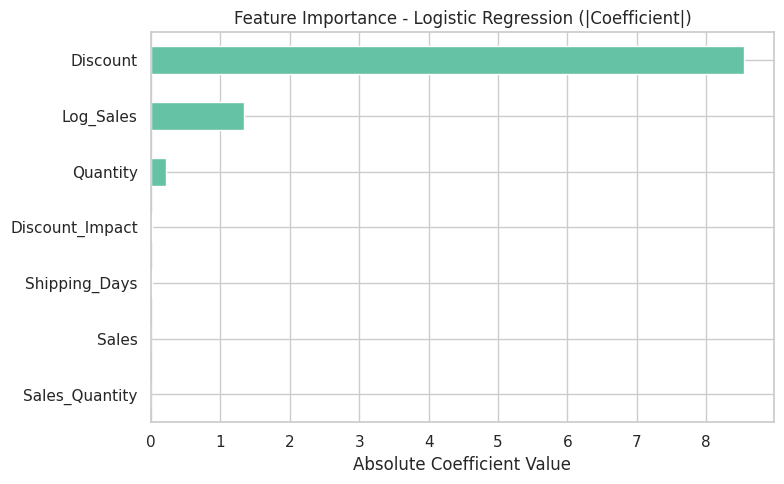

In [ ]:
# Feature importance cho Logistic Regression
fi_lr = pd.Series(
    lr.coef_[0],   # vì là binary classification
    index=X_train_sm.columns
)

# Sắp xếp theo độ lớn tuyệt đối
fi_lr_abs = fi_lr.abs().sort_values()

plt.figure(figsize=(8,5))
fi_lr_abs.plot(kind='barh')
plt.title("Feature Importance - Logistic Regression (|Coefficient|)")
plt.xlabel("Absolute Coefficient Value")
plt.tight_layout()
plt.show()


In [ ]:
#Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf.fit(X_train_sm, y_train_sm)
rf_pred = rf.predict(X_test)

print("=== RANDOM FOREST ===")
print(classification_report(y_test, rf_pred))

=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.95      0.80      0.87      1000
           1       0.83      0.96      0.89       999

    accuracy                           0.88      1999
   macro avg       0.89      0.88      0.88      1999
weighted avg       0.89      0.88      0.88      1999



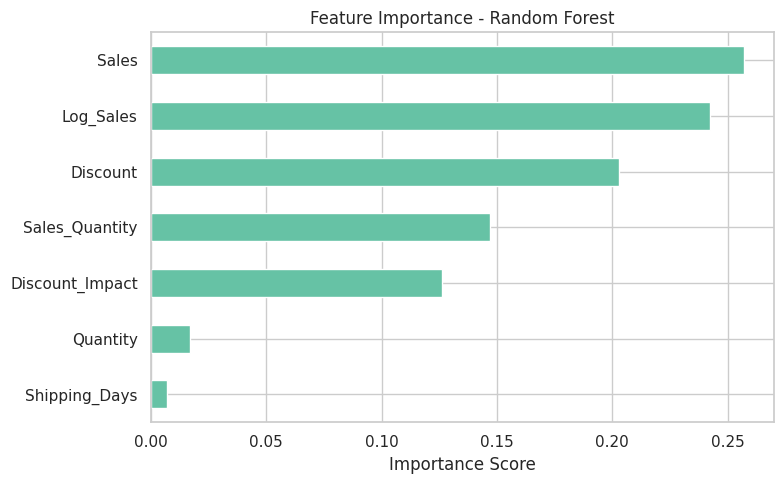

In [ ]:
# Feature importance cho Random Forest
fi_rf = pd.Series(
    rf.feature_importances_,
    index=X_train_sm.columns
).sort_values()

plt.figure(figsize=(8,5))
fi_rf.plot(kind='barh')
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


In [ ]:
#Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train_sm, y_train_sm)
gb_pred = gb.predict(X_test)

print("=== GRADIENT BOOSTING ===")
print(classification_report(y_test, gb_pred))

=== GRADIENT BOOSTING ===
              precision    recall  f1-score   support

           0       0.95      0.80      0.87      1000
           1       0.83      0.96      0.89       999

    accuracy                           0.88      1999
   macro avg       0.89      0.88      0.88      1999
weighted avg       0.89      0.88      0.88      1999



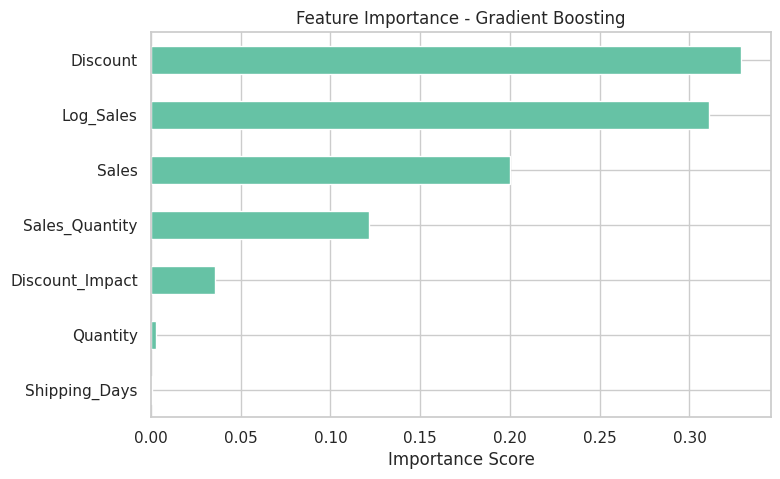

In [ ]:
fi = pd.Series(
    gb.feature_importances_,
    index=features
).sort_values()

plt.figure(figsize=(8,5))
fi.plot(kind='barh')
plt.title("Feature Importance - Gradient Boosting")
plt.xlabel("Importance Score")
plt.show()

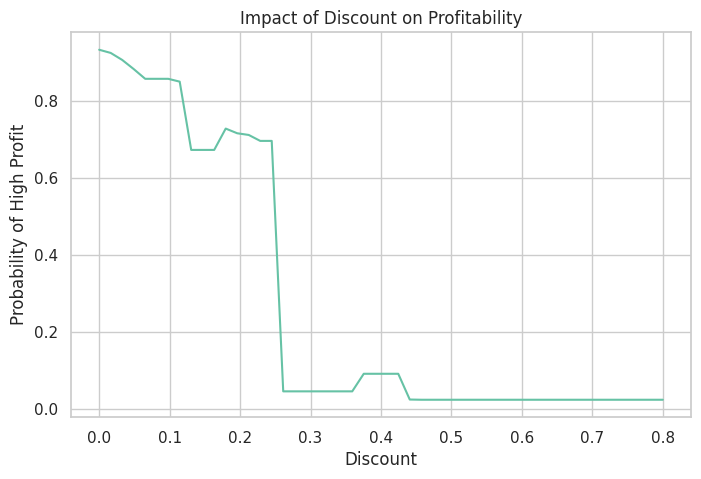

In [ ]:
discount_range = np.linspace(0, 0.8, 50)

sample = X_test.mean().to_frame().T
probs = []

for d in discount_range:
    temp = sample.copy()
    temp['Discount'] = d
    temp['Discount_Impact'] = temp['Sales'] * d
    probs.append(gb.predict_proba(temp)[0][1])

plt.figure(figsize=(8,5))
plt.plot(discount_range, probs)
plt.xlabel("Discount")
plt.ylabel("Probability of High Profit")
plt.title("Impact of Discount on Profitability")
plt.grid(True)
plt.show()


In [ ]:
compare_fi = pd.DataFrame({
    'Gradient Boosting': gb.feature_importances_,
    'Random Forest': rf.feature_importances_,
    'Logistic Regression (abs coef)': np.abs(lr.coef_[0])
}, index=X_train_sm.columns)

compare_fi


,Gradient Boosting,Random Forest,Logistic Regression (abs coef)
Sales,0.199948,0.257290,0.002227
Log_Sales,0.310767,0.242591,1.347653
Quantity,0.003081,0.017032,0.219898
Discount,0.328954,0.202752,8.548038
Discount_Impact,0.035473,0.126376,0.015997
Sales_Quantity,0.121279,0.147103,0.000110
Shipping_Days,0.000498,0.006856,0.012528
